In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from BACKTEST.backtestCalculateEVS import *
from BACKTEST.backtest import *
from MODELS.teamInfo import *

In [2]:
q10_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q10_modelv1.pkl')
q50_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q50_modelv1.pkl')
q90_model = joblib.load('../MODELS/SAVED_MODELS/xgb_q90_modelv1.pkl')
models = {'q10': q10_model, 'q50': q50_model, 'q90': q90_model}
features = joblib.load('../MODELS/SAVED_MODELS/feature_list.pkl')

In [3]:
pd.set_option('display.max_columns', None)
eplison = 0.000001

s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')

df = pd.concat([s25, s24]).sort_values(by='GAME_DATE')
date = '2024-11-27'

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['CATEGORY'] == 'player_points') & (backtestData['BOOKMAKER'] == 'underdog')]
backtestData

/var/folders/nw/9w4r5hrd05s122kt5hg_t8bw0000gn/T/ipykernel_88738/708601484.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
21,21,21,21,Josh Hart,player_points,underdog,over,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
22,22,22,22,Josh Hart,player_points,underdog,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
23,23,23,23,Luke Kornet,player_points,underdog,over,5.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
24,24,24,24,Luke Kornet,player_points,underdog,under,5.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
25,25,25,25,Sam Hauser,player_points,underdog,over,6.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198098,198098,198098,119137,Garrett Temple,player_points,underdog,over,10.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,115.0,over
198101,198101,198101,119140,Harrison Barnes,player_points,underdog,over,8.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,124.0,over
198103,198103,198103,119142,Harrison Barnes,player_points,underdog,under,8.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-124.0,under
198107,198107,198107,119146,Chris Paul,player_points,underdog,over,5.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,6.0,100.0,over


In [5]:
results = backtestTrios(
    data=df,
    backtestData=backtestData,
    gameDate='2024-12-22',
    models=models,  
    features=features,
    edge_threshold=0.10,  
    top_n=10
)

In [6]:
results

,player1,player2,player3,model_side1,model_side2,model_side3,line1,line2,line3,pred1,pred2,pred3,q10_1,q90_1,q10_2,q90_2,q10_3,q90_3,actual1,actual2,actual3,edge1,edge2,edge3,leg1_won,leg2_won,leg3_won,parlay_recommendation,parlay_won,ev_percent,kelly_full,prob_all_three,combined_edge,date
0,Kevin Huerter,Aaron Gordon,Peyton Watson,under,over,over,8.5,12.5,5.5,6.22,14.88,8.37,1.85,14.04,6.99,22.92,2.2,14.59,8,17,5,0.090,0.058,0.127,1,1,0,0,0,79.79,0.160,0.2997,0.092,2024-12-22
1,Kevin Huerter,T.J. McConnell,Peyton Watson,under,over,over,8.5,10.5,5.5,6.22,12.32,8.37,1.85,14.04,4.97,19.52,2.2,14.59,8,12,5,0.090,0.036,0.127,1,1,0,0,0,73.73,0.147,0.2896,0.085,2024-12-22
2,Kevin Huerter,Kelly Olynyk,Peyton Watson,under,under,over,8.5,7.5,5.5,6.22,6.09,8.37,1.85,14.04,1.10,13.48,2.2,14.59,8,8,5,0.090,0.027,0.127,1,0,0,0,0,71.00,0.142,0.2850,0.081,2024-12-22
3,Kevin Huerter,Gradey Dick,Peyton Watson,under,over,over,8.5,15.5,5.5,6.22,17.44,8.37,1.85,14.04,8.70,26.70,2.2,14.59,8,14,5,0.090,0.021,0.127,1,0,0,0,0,69.38,0.139,0.2823,0.079,2024-12-22
4,Kevin Huerter,Fred VanVleet,Peyton Watson,under,over,over,8.5,15.5,5.5,6.22,17.13,8.37,1.85,14.04,8.55,26.68,2.2,14.59,8,2,5,0.090,0.005,0.127,1,0,0,0,0,64.75,0.130,0.2746,0.074,2024-12-22
5,T.J. McConnell,Aaron Gordon,Peyton Watson,over,over,over,10.5,12.5,5.5,12.32,14.88,8.37,4.97,19.52,6.99,22.92,2.2,14.59,12,17,5,0.036,0.058,0.127,1,1,0,0,0,65.33,0.131,0.2755,0.074,2024-12-22
6,Kevin Huerter,Tyrese Haliburton,Peyton Watson,under,over,over,8.5,18.5,5.5,6.22,20.02,8.37,1.85,14.04,10.62,28.62,2.2,14.59,8,14,5,0.090,-0.000,0.127,1,0,0,0,0,63.36,0.127,0.2723,0.072,2024-12-22
7,Kevin Huerter,Russell Westbrook,Peyton Watson,under,over,over,8.5,10.5,5.5,6.22,11.71,8.37,1.85,14.04,4.38,19.65,2.2,14.59,8,21,5,0.090,-0.005,0.127,1,1,0,0,0,61.98,0.124,0.2700,0.071,2024-12-22
8,Kelly Olynyk,Aaron Gordon,Peyton Watson,under,over,over,7.5,12.5,5.5,6.09,14.88,8.37,1.10,13.48,6.99,22.92,2.2,14.59,8,17,5,0.027,0.058,0.127,0,1,0,0,0,62.73,0.125,0.2712,0.071,2024-12-22
9,Kevin Huerter,Myles Turner,Peyton Watson,under,over,over,8.5,13.5,5.5,6.22,14.74,8.37,1.85,14.04,6.59,22.95,2.2,14.59,8,15,5,0.090,-0.008,0.127,1,1,0,0,0,61.14,0.122,0.2686,0.070,2024-12-22


In [7]:
uniqueDates = sorted(s25['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestTrios(
        data=df,
        backtestData=backtestData,
        gameDate='2024-12-22',
        models=models,  
        features=features,
        edge_threshold=0.10,  
        top_n=10
    )
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162


KeyboardInterrupt: 

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,410
   Wins: 552
   Hit Rate: 39.15%
   Total Profit: $9,510.00
   Total Staked: $7,050.00
   ROI: 134.89%
   Volatility: $112.33
   Max Drawdown: $-180.00
   Sharpe Ratio: 7.129

 RECOMMENDED BETS ANALYSIS (Edge > 4.5):
   Total Bets: 1,167
   Wins: 504
   Hit Rate: 43.19%
   Total Profit: $9,285.00
   Total Staked: $5,835.00
   ROI: 159.13%
   Volatility: $111.80
   Max Drawdown: $-120.00
   Sharpe Ratio: 7.399


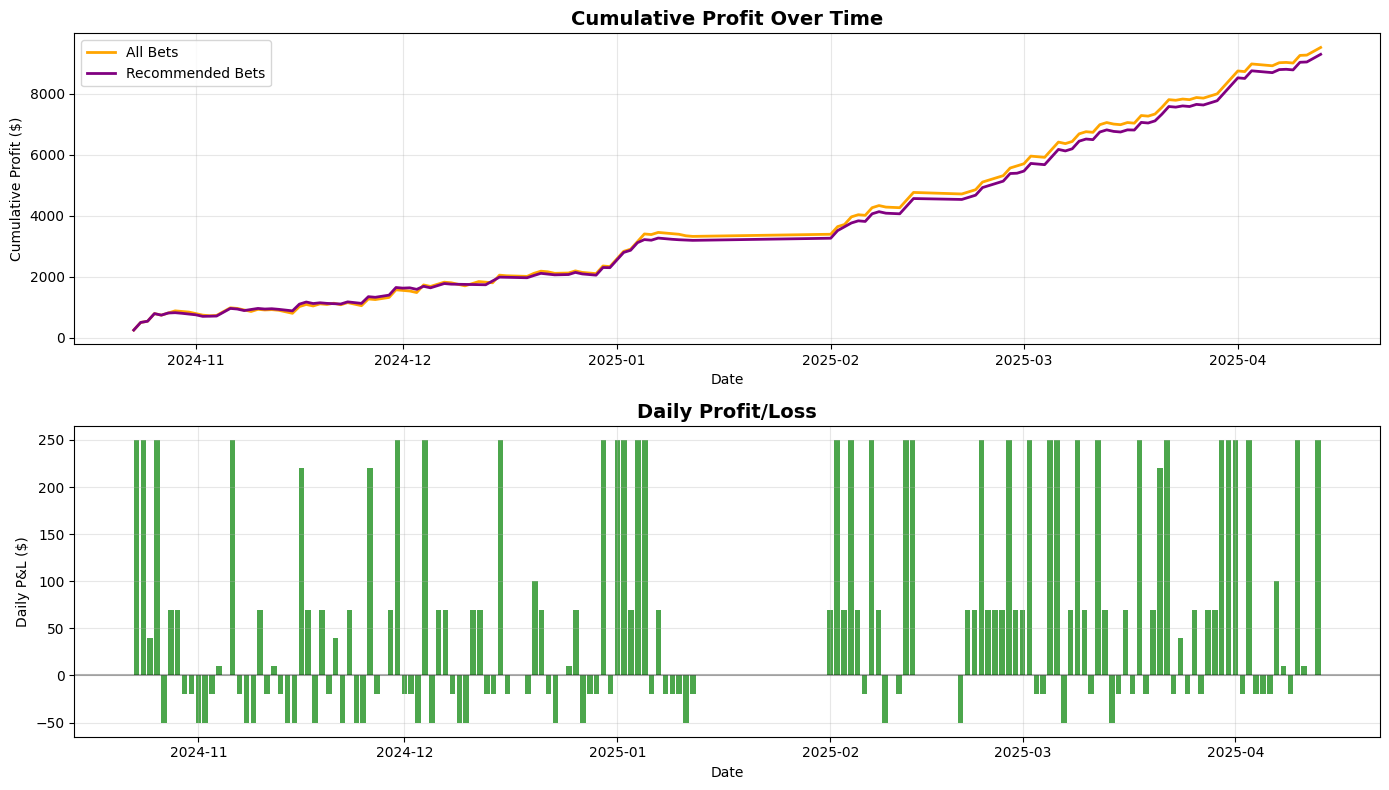

In [ ]:
# Calculate metrics for all 3-leg bets
all_metrics = calculate3LegMetrics(final_results, stake=5)
edge = 4.5

# Calculate metrics for recommended 3-leg bets only (edge > threshold)
recommended_3legs = final_results[final_results['parlay_recommendation'] == 1]
rec_metrics = calculate3LegMetrics(recommended_3legs, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()